In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = "results/{0}_fig10_rho_critical.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 32000
M = np.empty((len(N_range), num_ensambles))

In [6]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

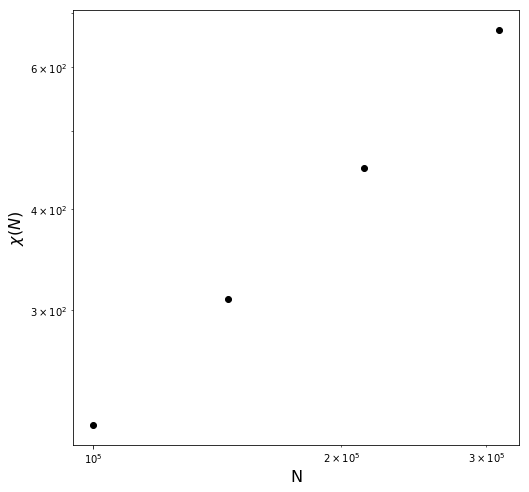

In [7]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)
plt.figure(figsize=(8,8))
plt.loglog(*pairs[:,:2].T, 'ko')
plt.xlabel('N', fontsize=16)
plt.ylabel(r'$\chi (N)$', fontsize=16)
plt.show()